# Part A – Transformers
### **Total Marks: 50**  
### `Name: Muhammad Bilal Hassan`
### `Roll Number: 28100371`

---

## Assignment Structure

This part of the assignment consists of **three tasks**, each focusing on a different aspect of Transformer models — from implementation to analysis and applications.

### **Task 1: Transformer Implementation from Scratch**  
You will implement a mini Transformer-based language model from scratch using PyTorch.  
This task evaluates your understanding of core components such as self-attention, feedforward networks, residual connections, and text generation.

### **Task 2: Understanding Transformer Attention**  
You will analyze and interpret attention visualizations from Transformer models.  
This task focuses on understanding attention behavior across layers and heads, and reflecting on the interpretability of attention mechanisms.

### **Task 3: Applications of Pretrained Transformers**   
You will explore practical applications of pretrained Transformer models and reflect on their strengths and limitations compared to models trained from scratch.

---



---


## Instructions

<table style="width:100%; table-layout:fixed;">
<tr>

<td style="vertical-align:top; padding:12px; width:33%;">
  <h3 style="margin:0 0 8px 0; font-weight:800; color:#e53935;">
    Plagiarism Policy
  </h3>
  <ul style="margin:6px 0 0 18px; padding:0; color:#e53935;">
    <li>
      <strong>All work must be done independently.</strong><br>
      Any plagiarism or cheating (from peers or the internet) will be immediately referred to the DC.
      If you are unsure what constitutes plagiarism, consult the TAs in a timely manner.
    </li>
    <li style="margin-top:8px;">
      <strong>Do not look at anyone else’s code.</strong>
    </li>
  </ul>
</td>

<td style="vertical-align:top; padding:12px; width:33%;">
  <h3 style="margin:0 0 8px 0; font-weight:800; color:#e53935;">
    Submission Instructions
  </h3>
  <ul style="margin:6px 0 0 18px; padding:0; color:#e53935;">
    <li>
      Submit <strong>all</strong> required <code>.ipynb</code> and <code>.py</code> files on LMS
      (search how to extract scripts if confused).
    </li>
    <li style="margin-top:8px;">
      <strong>Submissions via Dropbox or email will not be accepted.</strong>
    </li>
    <li style="margin-top:8px;">
      Zip your files as <code>RollNumber_PAx.zip</code> and ensure your roll number is filled in correctly.
    </li>
    <li style="margin-top:8px;">
      <strong>Deviation from the naming convention will result in a penalty.</strong>
    </li>
    <li style="margin-top:8px;">
      <strong>Expected file structure:</strong>
    </li>
  </ul>
  <pre style="margin:8px 0 0 0; font-size:90%; color:#e53935;">
26100076_PA3.zip
├─ 26100076_PA3.ipynb
└─ 26100076_PA3.py
  </pre>
</td>

<td style="vertical-align:top; padding:12px; width:33%;">
  <h3 style="margin:0 0 8px 0; font-weight:800; color:#e53935;">
    General Instructions
  </h3>
  <ul style="margin:6px 0 0 18px; padding:0; color:#e53935;">
    <li>
      <strong>Ensure all cells are executed before submission.</strong>
    </li>
    <li style="margin-top:8px;">
      <strong>Do not remove or modify any pre-written code.</strong>
    </li>
    <li style="margin-top:8px;">
      <strong>All parts of the assignment must be attempted.</strong>
    </li>
  </ul>
</td>

</tr>
</table>


<div style="display: flex; align-items: center; gap: 24px;">

<div style="flex: 2;">

# Transformers — An Introduction

Transformers are a modern neural network architecture designed to process sequential data such as text, audio, and images. Introduced in the paper “Attention Is All You Need”, transformers marked a major shift in how sequence modeling problems are approached. Earlier architectures such as recurrent neural networks (RNNs) and convolutional neural networks (CNNs) processed sequences step-by-step or through local receptive fields, which made it difficult to capture long-range relationships and limited their ability to scale efficiently. Transformers replaced these mechanisms with attention, allowing models to directly relate all elements of a sequence to one another.

At a high level, transformers operate by first converting input tokens into numerical vector representations known as embeddings. These embeddings capture semantic and contextual information about tokens and serve as the starting point for further processing. Through the attention mechanism, each token is able to dynamically determine which other tokens in the sequence are most relevant to it. This allows the model to capture dependencies regardless of distance, making it particularly effective for language and other structured data where relationships may span long contexts.

A transformer is composed of multiple stacked layers, where each layer refines the representations produced by the previous one. Within each layer, multi-head attention enables the model to focus on different types of relationships simultaneously, while feedforward networks introduce non-linear transformations that increase expressive power. Skip connections and normalization layers help stabilize training, allowing very deep models to be trained effectively without suffering from optimization issues.

One of the most important advantages of transformers is their ability to process entire sequences in parallel, which significantly improves training efficiency on modern hardware such as GPUs and TPUs. This scalability has enabled the development of extremely large models trained on massive datasets, leading to breakthroughs across natural language processing, computer vision, speech recognition, and multimodal AI.

Today, transformers form the foundation of most state-of-the-art AI systems, including large language models, machine translation systems, recommendation engines, and many emerging generative AI applications. This document provides an intuitive overview of the key components that make transformers effective, building toward an understanding of how these models can be implemented and applied in practice.

For more information, please go through this paper:
https://arxiv.org/abs/1706.03762

</div>

<div style="flex: 1; text-align: center;">
  <img src="AttentionImage.webp" alt="Transformer Architecture" width="100%">
</div>

</div>


# Task 1: Transformer Implementation from Scratch
In this section, you will implement a **decoder-only Transformer** language model entirely from scratch using PyTorch. The goal is to understand how modern language models are constructed by assembling smaller components step-by-step. Each component will be implemented independently before being combined into a final model.

## Creating the Dataset (2 marks)

For this assignment, you will use the **WikiText dataset**, a collection of curated Wikipedia articles commonly used for language modeling research.

The dataset contains long-form natural text with proper sentence structure and minimal preprocessing, making it suitable for studying sequence modeling and next-token prediction.

---

### 1. Dataset Setup

Download and load the dataset. Briefly describe:

- what the dataset contains,
- why it is suitable for language modeling,
- and any important characteristics such as size or structure.

---

### 2. Preprocessing and Tokenization

Prepare the dataset for training by:

- applying **subword-level tokenization**,
- constructing token sequences suitable for next-token prediction,
- converting the data into input (`x`) and target (`y`) sequences.

You must use **subword tokenization**. Libraries such as `tiktoken` may be used for this purpose.

> **Note:** Character-level tokenization is **not allowed** in this assignment.


In [ ]:
import torch
import requests
import tiktoken

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 32
BLOCK_SIZE = 128   # context length

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

"""
TODO:

Download and load the dataset text.

You may use the provided URL below. The dataset should be loaded
as a single string called `text`.

Steps:
1. Send a request to the URL
2. Read the response text
3. Optionally save it locally
4. Print the number of characters loaded
"""

url = "https://www.gutenberg.org/cache/epub/36034/pg36034.txt"
response = requests.get(url)


# TODO: Load the dataset text
text = response.text

# Example checks (do not remove)
print("Loaded", len(text), "characters.")
print(text[:500])


# ------------------------------------------------------------
# 2. Tokenization (Subword-Level)
# ------------------------------------------------------------

"""
TODO:

Tokenize the dataset using subword-level tokenization.

Requirements:
- Use the tiktoken GPT-2 encoding
- Convert the encoded tokens into a torch tensor
- Tensor dtype should be torch.long

Hint:
encoder.encode(text) returns a list of token IDs.
"""

encoder = tiktoken.get_encoding("gpt2")

# TODO: Encode the dataset
data = torch.tensor(encoder.encode(text), dtype=torch.long)

print(f"Dataset size: {len(data)} tokens")


# ------------------------------------------------------------
# 3. Train / Validation Split
# ------------------------------------------------------------

"""
TODO:

Split the dataset into training and validation portions.

Use:
- 90% for training
- 10% for validation
"""
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Validation tokens:", len(val_data))


# ------------------------------------------------------------
# 4. Batch Sampling Function
# ------------------------------------------------------------

def get_batch(split="train"):
    """
    Returns a batch (x, y) for next-token prediction.

    x : tokens [t ... t+n-1]
    y : tokens [t+1 ... t+n]

    TODO:

    1. Select the correct dataset split
    2. Sample random starting indices
    3. Construct input sequences of length BLOCK_SIZE
    4. Construct target sequences shifted by one token
    5. Move tensors to the correct device
    """

    source = train_data if split == "train" else val_data

    # TODO: Sample random starting indices
    idxs = torch.randint(0, len(source) - BLOCK_SIZE, (BATCH_SIZE,))

    # TODO: Create input and target batches
    x = torch.stack([source[idx : idx + BLOCK_SIZE] for idx in idxs])
    y = torch.stack([source[idx + 1 : idx + BLOCK_SIZE + 1] for idx in idxs])

    # TODO: Ensure correct dtype and device
    x = x.long().to(device)
    y = y.long().to(device)

    return x, y

Loaded 682240 characters.
﻿The Project Gutenberg eBook of White nights, and other stories
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
befor
Dataset size: 185934 tokens
Train tokens: 167340
Validation tokens: 18594


In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

xb, yb = get_batch()

print("xb shape:", xb.shape)  # (BATCH_SIZE, BLOCK_SIZE)
print("yb shape:", yb.shape)  # (BATCH_SIZE, BLOCK_SIZE)

print("\nSanity check: next-token alignment")
print("First sequence (x):")
print(xb[0][:10].tolist())

print("First sequence (y):")
print(yb[0][:10].tolist())

print("Check shift (x[0][1:] == y[0][:-1]):",
      torch.all(xb[0][1:] == yb[0][:-1]).item())


print("\nDataset split check:")
print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))
print("Train %:", len(train_data) / (len(train_data) + len(val_data))) ## should be 0.9 (i hope they all saw this)


xb shape: torch.Size([32, 128])
yb shape: torch.Size([32, 128])

Sanity check: next-token alignment
First sequence (x):
[257, 10813, 11, 290, 611, 339, 857, 201, 198, 1662]
First sequence (y):
[10813, 11, 290, 611, 339, 857, 201, 198, 1662, 11]
Check shift (x[0][1:] == y[0][:-1]): True

Dataset split check:
Train tokens: 167340
Val tokens: 18594
Train %: 0.8999967730485011


## Defining Hyperparameters

Transformers contain several architectural choices that control model size, capacity, and computational cost. Instead of passing these values individually throughout the code, we collect them inside a configuration object.

This makes experimentation easier and keeps the implementation clean.

Some important parameters:

- **block_size** — maximum sequence length processed by the model.
- **emb_dim** — dimensionality of token embeddings and hidden representations.
- **head_dim** — dimensionality of each attention head.
- **num_heads** — number of attention heads used in attention.
- **num_layers** — number of stacked Transformer blocks.
- **vocab_size** — number of tokens in the tokenizer vocabulary.

In [ ]:
## already done(PLEASE DO NOT EDIT)

from dataclasses import dataclass

@dataclass
class ModelConfig:
    block_size: int = BLOCK_SIZE
    emb_dim: int = 256
    head_dim: int = 32
    num_heads: int = 8
    num_layers: int = 2
    vocab_size: int = encoder.n_vocab

cfg = ModelConfig()

assert cfg.emb_dim == cfg.head_dim * cfg.num_heads, \
    "Embedding dimension must equal head_dim * num_heads"

## Multi-Head Self-Attention (5 marks)
Self-attention allows each token in a sequence to dynamically attend to other tokens. This mechanism enables the model to capture relationships across long distances without recurrence or convolution.

The attention operation can be summarized as:

$$
\text{Attention}(Q, K, V) =
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In multi-head attention, this process is performed multiple times in parallel, allowing the model to learn different types of relationships simultaneously.



In [ ]:
# ============================================================
# Multi-Head Self-Attention
# ============================================================

import torch.nn as nn # It is giving me error otherwise so i import it

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.emb_dim = cfg.emb_dim
        self.head_dim = cfg.head_dim
        self.num_heads = cfg.num_heads
        self.block_size = cfg.block_size

        # TODO: define projection layers
        self.qkv_proj = nn.Linear(self.emb_dim, 3 * self.emb_dim)
        self.out_proj = nn.Linear(self.emb_dim, self.emb_dim)

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(self.block_size, self.block_size))
        )

    def forward(self, x):

        B, T, C = x.shape
        H = self.num_heads

        # TODO: compute Q, K, V projections
        qkv = self.qkv_proj(x)  #  it is (B,T,3*C)

        # TODO: reshape and separate into q, k, v
        q, k, v = torch.chunk(qkv, 3, dim=-1)  # each is (B,T,C)

        # Did tanspose to switch from (B,T,C) to (B,H,T,head_dim)
        q = q.view(B, T, H, self.head_dim).transpose(1, 2)  # (B,H,T,head_dim)
        k = k.view(B, T, H, self.head_dim).transpose(1, 2)  # (B,H,T,head_dim)
        v = v.view(B, T, H, self.head_dim).transpose(1, 2)  # (B,H,T,head_dim)

        # TODO: attention scores and masking
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)  # (B,H,T,T)
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))  # Mask out future tokens
        weights = torch.softmax(scores, dim=-1)  # (B,H,T,T)

        # TODO: weighted sum and merge heads
        out = torch.matmul(weights, v)  # (B,H,T,head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # (B,T,C)

        # TODO: final projection
        out = self.out_proj(out)

        return out


In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

attn = MultiHeadSelfAttention(cfg).to(device)

x = torch.randn(2, cfg.block_size, cfg.emb_dim, device=device)
y = attn(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

assert y.shape == x.shape, "Forward pass output shape is incorrect"
assert torch.isfinite(y).all(), "Output contains NaN or Inf"


Input shape: torch.Size([2, 128, 256])
Output shape: torch.Size([2, 128, 256])


## Feedforward Network (4 marks)
After attention mixes information across tokens, each token representation is processed independently through a small neural network. This stage introduces non-linearity into the model and allows it to learn more expressive transformations of the attended representations.

In this implementation, the feedforward module consists of:

- **GELU activation**, which provides smoother non-linearity compared to ReLU and is commonly used in modern Transformer models,
- **three linear layers**, where the dimensionality is first expanded, processed, and then projected back to the original embedding size,
- **dropout**, applied at the end of the module to improve generalization and reduce overfitting during training.


In [ ]:
# ============================================================
# Feedforward Network
# ============================================================

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        d = cfg.emb_dim

        # TODO: define linear layers
        self.fc1 = nn.Linear(d, 4 * d)  # Expansion layer
        self.fc2 = nn.Linear(4 * d, 4 * d)  # Processing layer
        self.fc3 = nn.Linear(4 * d, d)  # Projection back to embedding dim

        # TODO: define activation and dropout
        self.act = nn.GELU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):

        # TODO: apply feedforward transformations
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        x = self.dropout(x)

        return x


In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

ff = FeedForward(cfg).to(device)

x = torch.randn(2, cfg.block_size, cfg.emb_dim, device=device)
y = ff(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

assert y.shape == x.shape, "FeedForward output shape is incorrect"
assert torch.isfinite(y).all(), "FeedForward output contains NaN or Inf"


Input shape: torch.Size([2, 128, 256])
Output shape: torch.Size([2, 128, 256])


## Transformer Block with Residual Connections (5 marks)
A Transformer is constructed by stacking multiple identical blocks. Each block consists of the following components:

1. **Multi-head self-attention**, which allows tokens to attend to other tokens in the sequence.
2. **Feedforward network**, which applies non-linear transformations independently to each token.
3. **Layer normalization**, used to stabilize training.
4. **Residual (skip) connections**, which help gradients flow effectively through deep networks.

In this implementation, we use the **Pre-LayerNorm (Pre-LN)** design, where layer normalization is applied *before* each sub-layer. This approach has been shown to improve training stability, especially for deeper Transformer models.


In [ ]:
# ============================================================
# Transformer Block
# ============================================================

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # TODO: define attention and feedforward modules
        self.attn = MultiHeadSelfAttention(cfg)
        self.ffn = FeedForward(cfg)

        # TODO: define layer normalization layers
        self.ln1 = nn.LayerNorm(cfg.emb_dim)
        self.ln2 = nn.LayerNorm(cfg.emb_dim)

    def forward(self, x):

        # TODO: apply attention with residual connection
        x = x + self.attn(self.ln1(x))

        # TODO: apply feedforward with residual connection
        x = x + self.ffn(self.ln2(x))

        return x


In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

block = TransformerBlock(cfg).to(device)

x = torch.randn(2, cfg.block_size, cfg.emb_dim, device=device)
y = block(x)

print("Input shape:", x.shape)
print("Output shape:", y.shape)

assert y.shape == x.shape, "TransformerBlock output shape is incorrect"
assert torch.isfinite(y).all(), "TransformerBlock output contains NaN or Inf"

Input shape: torch.Size([2, 128, 256])
Output shape: torch.Size([2, 128, 256])


## Assembling the Language Model (5 marks)
We now combine all previously implemented components into a complete Transformer-based language model.

The model performs the following steps:

1. **Convert token indices into embeddings**, transforming discrete tokens into continuous vector representations.
2. **Add positional embeddings** to incorporate information about token order within the sequence.
3. **Pass the representations through a stack of Transformer blocks**, where attention and feedforward layers progressively refine the representations.
4. **Apply a final normalization layer and project the outputs to vocabulary logits**, which are used to predict the next token in the sequence.

---

### Generation Function

The function generates text autoregressively from a trained `MiniLM` model. The function trims the input to the model’s context length, predicts the next token, samples from the output distribution, and appends the result to the sequence.

In [ ]:
# ============================================================
# MiniGPT Model
# ============================================================

class MiniGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.block_size = cfg.block_size
        self.emb_dim = cfg.emb_dim
        self.vocab_size = cfg.vocab_size

        # TODO: define token and positional embeddings
        self.token_emb = nn.Embedding(self.vocab_size, self.emb_dim)
        self.pos_emb = nn.Embedding(self.block_size, self.emb_dim)

        # TODO: stack Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.num_layers)])

        # TODO: final normalization and output layer
        self.ln_f = nn.LayerNorm(self.emb_dim)
        self.lm_head = nn.Linear(self.emb_dim, self.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)

    def forward(self, idx):

        B, T = idx.shape
        assert T <= self.block_size

        # TODO: token and positional embeddings
        tok = self.token_emb(idx)  # (B,T,emb_dim)
        pos = self.pos_emb(torch.arange(T, device=idx.device))  # (T,emb_dim)

        # TODO: combine embeddings and pass through blocks
        x = tok + pos
        for block in self.blocks:
            x = block(x)

        # TODO: final normalization and projection
        x = self.ln_f(x)
        logits = self.lm_head(x)

        return logits


    @torch.no_grad()
    def generate(self, idxs, max_new_tokens=100, temperature=1.0):

        for _ in range(max_new_tokens):

            # TODO: crop sequence to block size
            idxs_cond = idxs[:, -self.block_size :]

            # TODO: forward pass
            logits = self(idxs_cond)

            # TODO: take last timestep logits
            logits = logits[:, -1, :]

            # TODO: temperature scaling and sampling
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # (B,1)

            # TODO: append generated token
            idxs = torch.cat((idxs, next_token), dim=1)

        return idxs


In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

model = MiniGPT(cfg).to(device)

# ---- forward() check ----
idx = torch.randint(0, cfg.vocab_size, (2, cfg.block_size), device=device)
logits = model(idx)

print("Input idx shape:", idx.shape)
print("Logits shape:", logits.shape)

assert logits.shape == (2, cfg.block_size, cfg.vocab_size), "Logits shape is incorrect"
assert torch.isfinite(logits).all(), "Logits contain NaN or Inf"

# ---- generate() check ----
start_idx = torch.randint(0, cfg.vocab_size, (1, 5), device=device)
out = model.generate(start_idx, max_new_tokens=40)

print("Generated shape:", out.shape)
assert out.shape[1] == 5 + 40, "Generated sequence length is incorrect"

# ---- decode and print output ----
print("\nGenerated text sample:")
print(encoder.decode(out[0].tolist()))


Input idx shape: torch.Size([2, 128])
Logits shape: torch.Size([2, 128, 50257])
Generated shape: torch.Size([1, 45])

Generated text sample:
 Paula subst Tuls pregnant Hol tirelesslyresents Sustainable Required nightmareslia daggerttpcare Croat Certain Zeus hasteドラゴン ped dollar pull Louisiana adversaries gradually crackdown Grant MultipleExactly retard asked stockp bloggers prompted laptopsFacebook vil volumeoland whom afar Pal registrations injuring loudspe


## Training the Transformer (5 marks)

After building the Transformer model, the next step is to train it on the prepared dataset. The model is trained demonstrate **next-token prediction**, where it learns to predict the next token in a sequence given the previous tokens.

At each training step:

1. A batch of input (`x`) and target (`y`) sequences is sampled from the dataset.
2. The input is passed through the Transformer to produce logits over the vocabulary.
3. Cross-entropy loss is computed between the predicted tokens and the true next tokens.
4. Gradients are computed using backpropagation.
5. Model parameters are updated using an optimizer.

We use the **AdamW optimizer**, along with a **learning rate scheduler**, to ensure stable training. Gradient clipping is also applied to prevent unstable updates.

Training can be accelerated using a GPU by moving both the model and input tensors to the same device. During training, the loss is tracked and plotted to monitor learning progress.

Once training is complete, the model can be used to generate text by predicting tokens autoregressively from an initial prompt.


In [ ]:
## DO NOT MODIFY. USE THIS CODE FOR THE NEXT PART

# ------------------------------------------------------------
# Create the model
# ------------------------------------------------------------

cfg = ModelConfig()
model = MiniGPT(cfg)

print(f"Number of parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M")

# ------------------------------------------------------------
# Training Configuration
# ------------------------------------------------------------

NUM_EPOCHS = 2000
LEARNING_RATE = 3e-4
EVAL_INTERVAL = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)

Number of parameters: 29.444M
Using device: cuda


In [ ]:
# ------------------------------------------------------------
# Optimizer and Scheduler
# ------------------------------------------------------------
import torch.optim as optim
import numpy as np


"""
TODO:

1. Define an optimizer for the model parameters.
2. Define a learning rate scheduler.

Recommended:
- AdamW optimizer
- Cosine annealing scheduler
"""

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ------------------------------------------------------------
# Training Loop
# ------------------------------------------------------------

"""
TODO:

Implement the full training loop.

Your loop should:

1. Sample a batch using get_batch()
2. Move tensors to the correct device
3. Perform a forward pass
4. Compute cross-entropy loss
5. Perform backpropagation
6. Update model parameters
7. Step the scheduler
8. Store loss values for plotting
9. Periodically print training progress
"""

model.train()

losses = []

for epoch in range(NUM_EPOCHS):

    # TODO: get training batch
    xb, yb = get_batch("train")

    # TODO: move to device
    xb = xb.to(device)
    yb = yb.to(device)

    # TODO: forward pass
    logits = model(xb)

    # TODO: reshape logits and targets
    B, T, C = logits.shape
    logits = logits.view(B * T, C)
    targets = yb.view(B * T)
    loss = nn.CrossEntropyLoss()(logits, targets)

    # TODO: backward pass and optimization step
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

    # TODO: update scheduler
    scheduler.step()

    # TODO: store loss value
    losses.append(loss.item())

    # TODO: print progress every EVAL_INTERVAL

    if (epoch + 1) % EVAL_INTERVAL == 0:
        avg_loss = np.mean(losses[-EVAL_INTERVAL:])
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"Loss: {loss.item():.4f} | "
            f"Avg Loss: {avg_loss:.4f}"
        )



print(f"\nTraining complete! Final loss: {losses[-1]:.4f}")



Epoch 50/2000 | Loss: 6.3446 | Avg Loss: 8.0837
Epoch 100/2000 | Loss: 5.4914 | Avg Loss: 5.8411
Epoch 150/2000 | Loss: 5.0496 | Avg Loss: 5.1781
Epoch 200/2000 | Loss: 4.5899 | Avg Loss: 4.7489
Epoch 250/2000 | Loss: 4.4243 | Avg Loss: 4.5084
Epoch 300/2000 | Loss: 4.1352 | Avg Loss: 4.3269
Epoch 350/2000 | Loss: 3.9758 | Avg Loss: 4.1560
Epoch 400/2000 | Loss: 4.0230 | Avg Loss: 4.0116
Epoch 450/2000 | Loss: 3.8870 | Avg Loss: 3.9058
Epoch 500/2000 | Loss: 3.7386 | Avg Loss: 3.8022


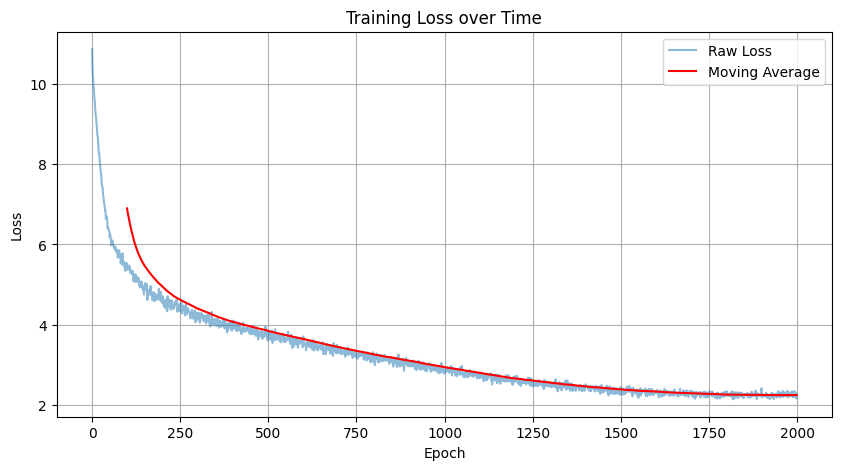

In [ ]:
# ------------------------------------------------------------
# Plot Training Curve
# ------------------------------------------------------------

import matplotlib.pyplot as plt

"""
TODO:

Plot the training loss curve.

Requirements:
- plot raw loss values
- plot a moving average curve
- label axes and title the plot
"""

plt.figure(figsize=(10, 5))

# TODO: plot raw loss
plt.plot(losses, label="Raw Loss", alpha=0.5)

# TODO: compute and plot moving average

window_size = 100
moving_avg = np.convolve(losses, np.ones(window_size) / window_size, mode="valid")
plt.plot(range(window_size - 1, len(losses)), moving_avg, label="Moving Average", color="red")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.legend()
plt.grid(True)
plt.show()

## Autoregressive Text Generation Using MiniLM

After training, the Transformer can be used to generate text by predicting one token at a time. This process is called **autoregressive generation**, where the model repeatedly uses its previous predictions as input to generate new tokens.

At each step:

1. The current sequence of tokens is passed through the model.
2. The model produces probabilities for the next token.
3. A token is sampled from this probability distribution.
4. The sampled token is appended to the sequence.
5. The process repeats until the desired number of tokens has been generated.

Since the model was trained for next-token prediction, generation follows the same principle used during training, but now the predictions are fed back into the model.


Once the model has been trained, text can be generated by providing an initial prompt. The prompt is first tokenized, passed into the model, and the generated tokens are decoded back into text.

In [ ]:
prompt = "The night was quiet and"
idxs = torch.tensor(encoder.encode(prompt)).unsqueeze(0).to(device)

model.eval()
generated_ids = model.generate(idxs, max_new_tokens=100)
generated_text = encoder.decode(generated_ids[0].tolist())
print(generated_text)


The night was quiet and a Rao twitching and in the same skirts of my tears. Half
inner which I could cigarettearg bagist upon us and overwhelmed
in Cro solder midst. Thislor volatile up of fear of its heap:
Osip Mihalitch_ uploading benz another money nine roubles a long
already. I'd prone to take grand style to wise laughter.

"What if I talked to say the samection for him our first little fish,


## Theoretical Questions (3 MARKS)

As you can see, your model is far more superior than anything OpenAI has launched in the market.  
Answer the following questions based on your generated output (3-5 sentences per question):

1. **Quality of Generation**  
   Identify **two things your model does well** and **two things it struggles with** in the generated text.  
   Briefly explain why these behaviors occur in **small Transformer models**.

2. **Effect of Model and Data Limitations**  
   How do the **size of the dataset** and the **size of the model** (e.g., number of layers, embedding dimension, number of heads) influence the **quality and coherence** of the generated text?

3. **Training vs. Generation Quality**  
   Even if the **training loss decreases over time**, the generated text may still lack meaning.  
   Explain why a **lower training loss does not always correspond to better or more coherent text generation**.


Answers to the above mentioned questions:

1. The model excels at local syntax. It puts the right words next to each other like "night was quiet". It mimics the syle of the training data. It fails global coherence. Its logic falls apart over thr long distances. It also fails at semantic consistency in such a way that phrase like "of no, of something in this horse" are grammatically plausible but nonsense. In small transformer models, the hidden state capacity is limited. with only a few layers and heads, the model can effectively attend to immediate the context but lacks depth to build a stable internal "world model" or track a narrative state across the entire sequence.

2. Increasing the dataset to large and massive datasets prevents overfitting and teaches the model broadly. It is cruicial for generalization. If the dataset is small it just start memorizing the specific transitions but if it is large it starts to understand the underlying logic of how concepts relate to one another. The model size, increasing the layers and embedding dimensions expands model's high dimensional space, allowing the model to learn more complex features which improves coherence. More heads allow the model to track multiple relationships simultaneously. like one head for focusing on subject verb agreement while other tracks the emotional tone.

3. A lower training loss indicates that the model is getting better at predicting the likely next token based on the training dataset, but it does not gurantee logical reasoning. The loss can be very low if the model just memorize the training data, which results in micking the fragments without understanding the contextual meaning. Moreover, autoregressive generation is influenced by the sampling method which during generation introduces randomness.

## Task 2 — Understanding Transformer Attention

So far in this assignment, you have implemented a Transformer from scratch. In this section, we move one step deeper and examine **what happens inside a Transformer during inference**.

One of the defining features of Transformers is the **attention mechanism**, which allows each token in a sequence to dynamically focus on other tokens when forming its representation.

Recall that in self-attention, each token computes attention scores with respect to every other token in the sequence:

$$
\text{Attention}(Q, K, V) =
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

The resulting attention weights describe **how strongly one token attends to another**. These weights can be interpreted as a form of learned relationship between tokens.

For example, in the sentence:
"The scientist who discovered radium won a Nobel Prize."


the token *"who"* may attend strongly to *"scientist"*, indicating a grammatical relationship.

---

### Why Analyze Attention?

Attention analysis helps answer questions such as:

- Which words influence each other during processing?
- Do different attention heads learn different patterns?
- Does attention focus locally (nearby words) or globally (long-range dependencies)?

In research and industry, attention visualization is often used to:

- debug model behavior,
- study linguistic patterns learned by models,
- interpret model decisions,
- understand failure cases.

It is important to note that attention weights are **not perfect explanations**, but they provide useful insight into how Transformers distribute focus across tokens.

In this task, you will extract and analyze attention weights from a pretrained Transformer model to better understand how attention operates in practice.


### The Task (5 MARKS)
In this task, you will analyze attention patterns from a pretrained Transformer model. Instead of generating or classifying text, your goal is to **inspect and interpret the internal attention behavior** of the model.

This task is more algorithmic than previous tasks and requires working directly with model outputs.

---

### Objective

You will:

1. Load a pretrained Transformer model that exposes attention weights.
2. Pass input sentences through the model.
3. Extract attention matrices from one or more layers.
4. Visualize attention patterns using heatmaps.
5. Analyze how attention is distributed across tokens.

In [ ]:
# ------------------------------------------------------------
# Mandatory Test Sentences (Do Not Modify)
# ------------------------------------------------------------
ATTENTION_TEST_SENTENCES = [
    "The scientist who discovered radium won a Nobel Prize.",
    "The dog chased the cat because it was scared.",
    "Artificial intelligence is transforming modern industries.",
    "The book that the professor recommended was difficult to understand."
]

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

Loading model with attention outputs...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!

Sentence 1:
The scientist who discovered radium won a Nobel Prize.

Tokens:
['[CLS]', 'the', 'scientist', 'who', 'discovered', 'ra', '##dium', 'won', 'a', 'nobel', 'prize', '.', '[SEP]']



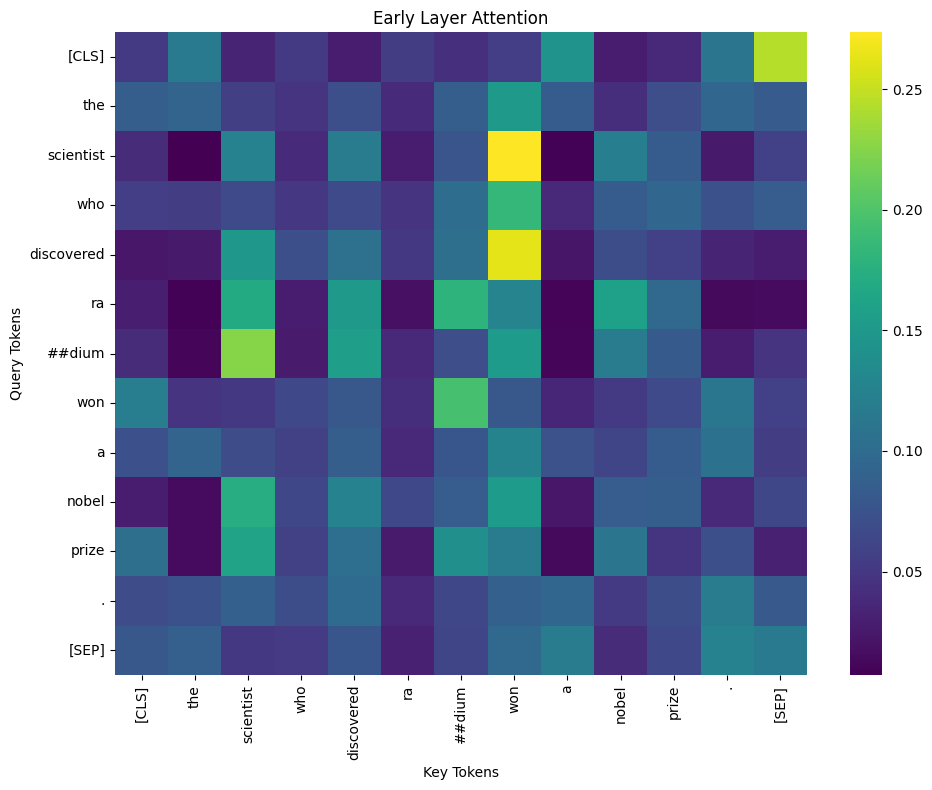

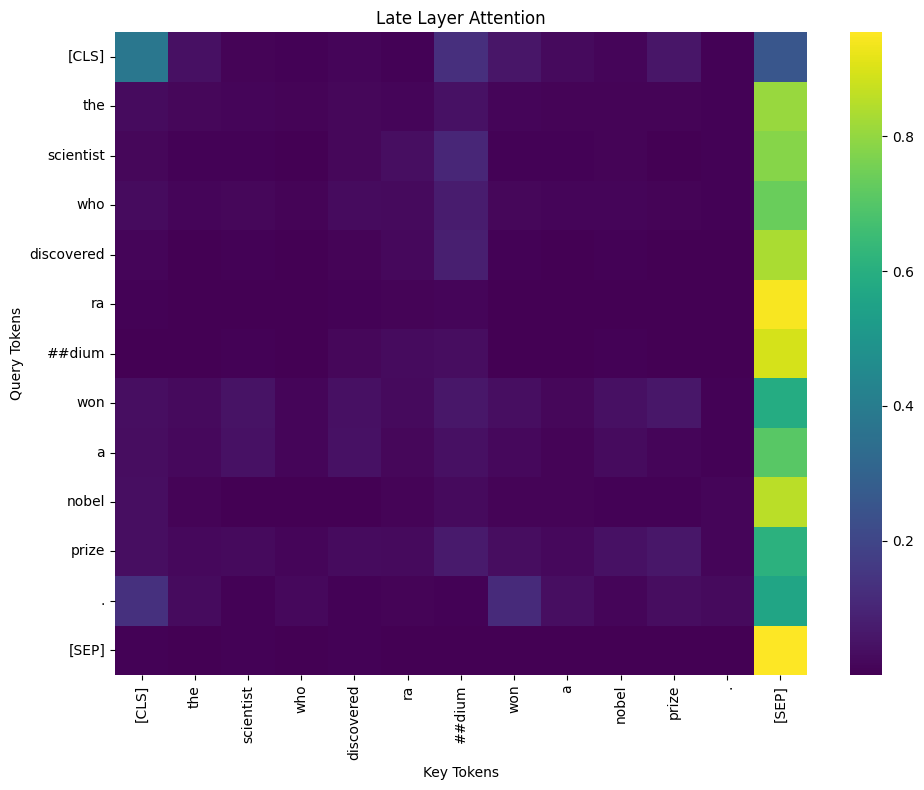

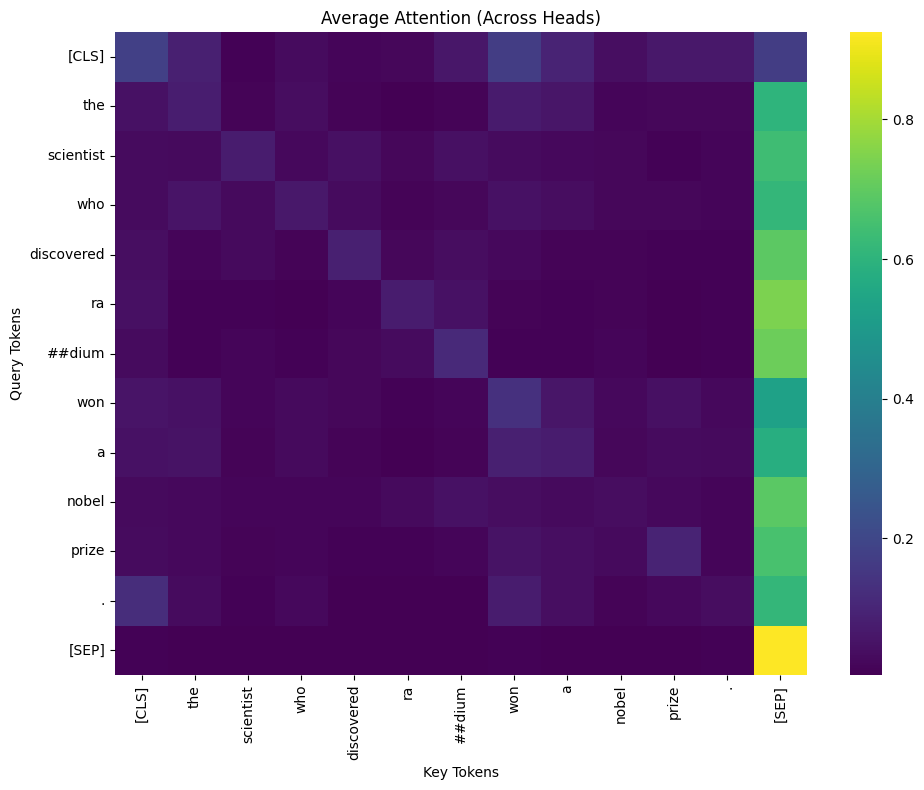

Sentence 2:
The dog chased the cat because it was scared.

Tokens:
['[CLS]', 'the', 'dog', 'chased', 'the', 'cat', 'because', 'it', 'was', 'scared', '.', '[SEP]']



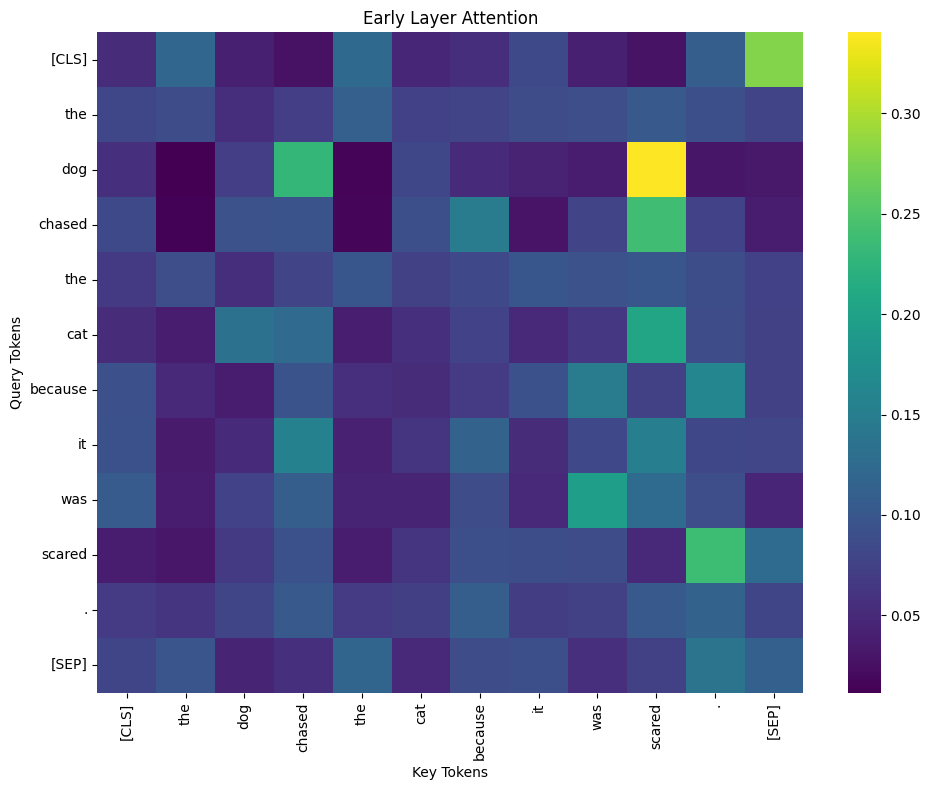

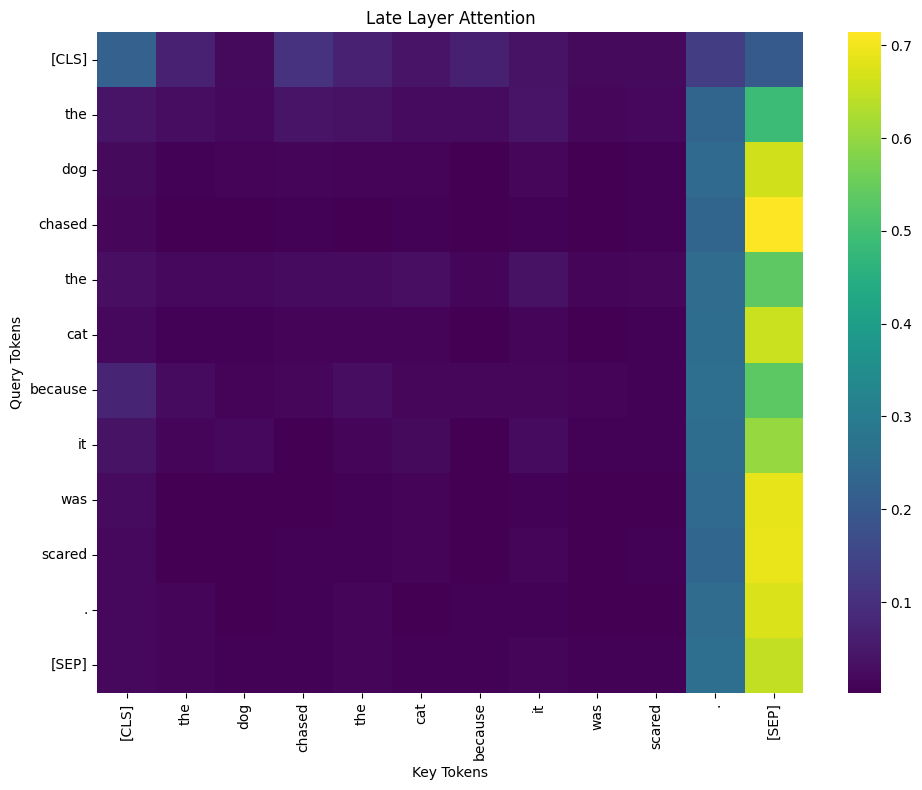

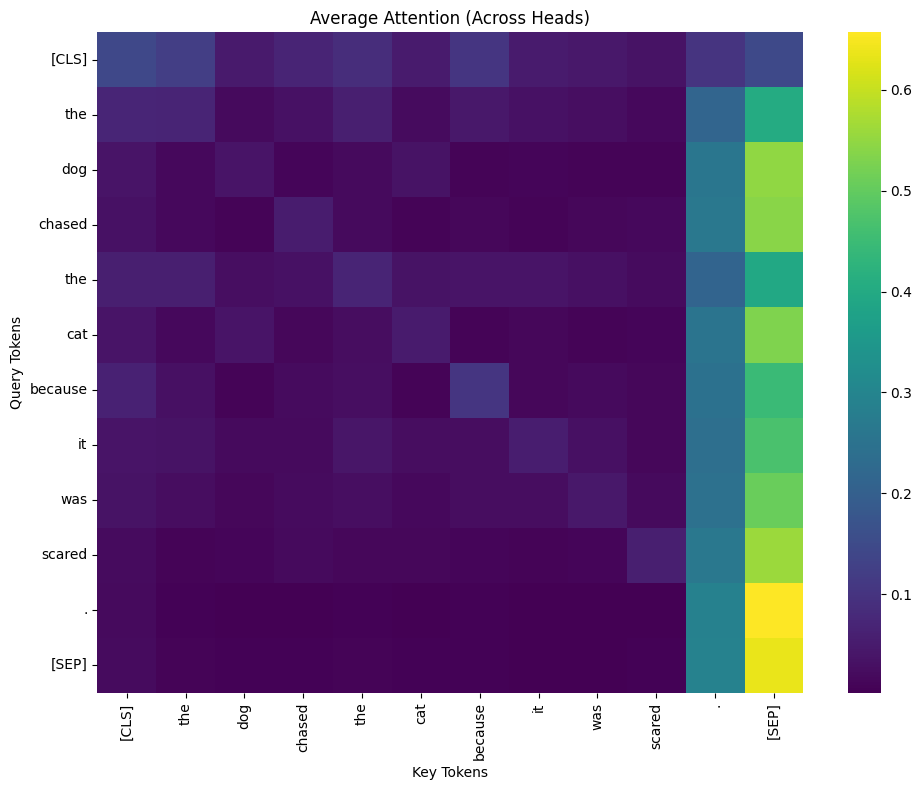

Sentence 3:
Artificial intelligence is transforming modern industries.

Tokens:
['[CLS]', 'artificial', 'intelligence', 'is', 'transforming', 'modern', 'industries', '.', '[SEP]']



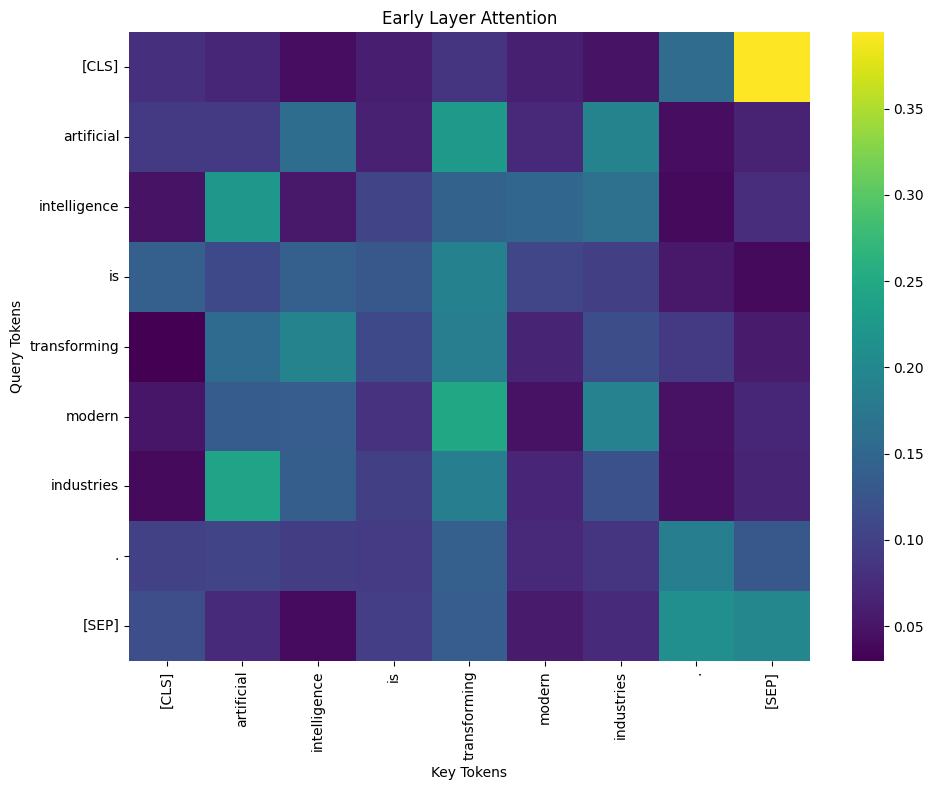

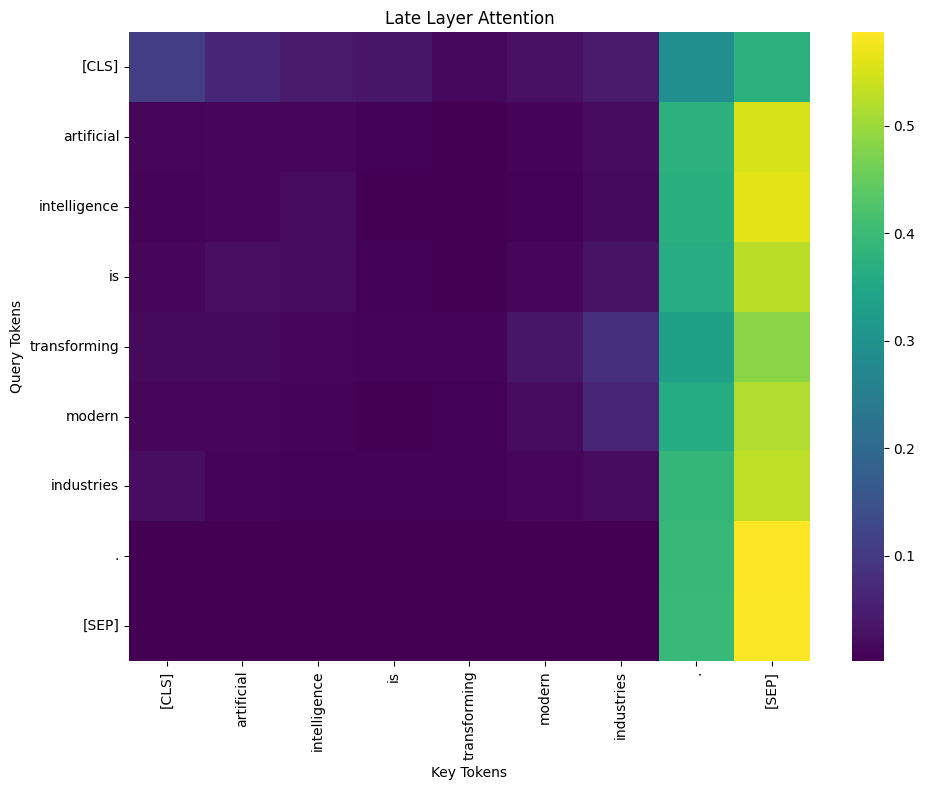

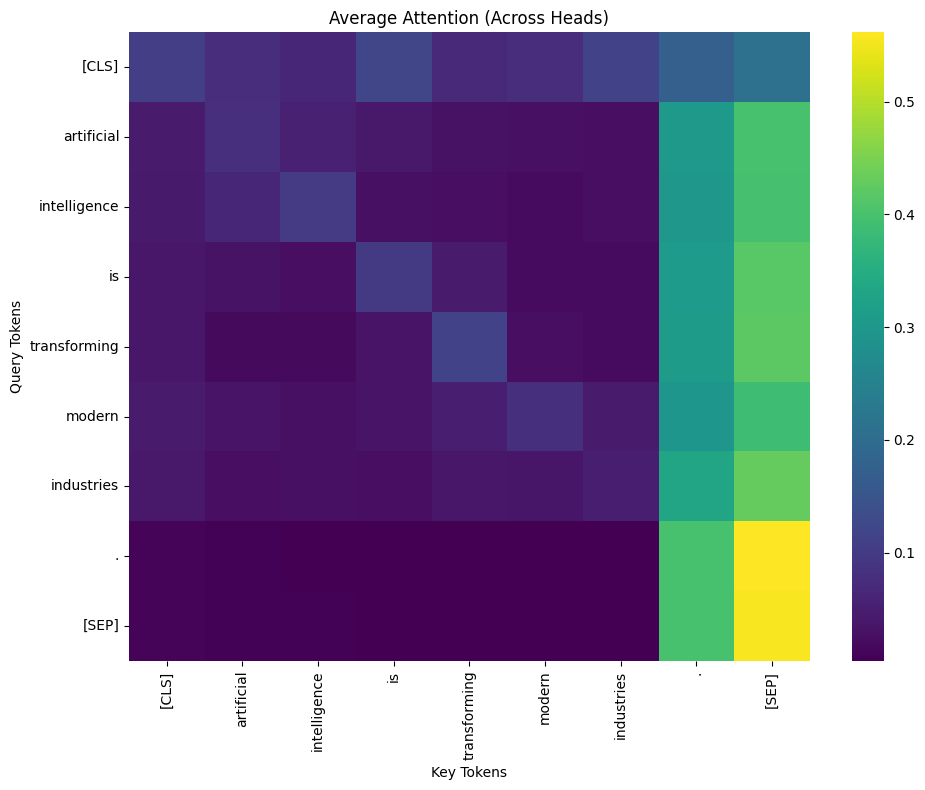

Sentence 4:
The book that the professor recommended was difficult to understand.

Tokens:
['[CLS]', 'the', 'book', 'that', 'the', 'professor', 'recommended', 'was', 'difficult', 'to', 'understand', '.', '[SEP]']



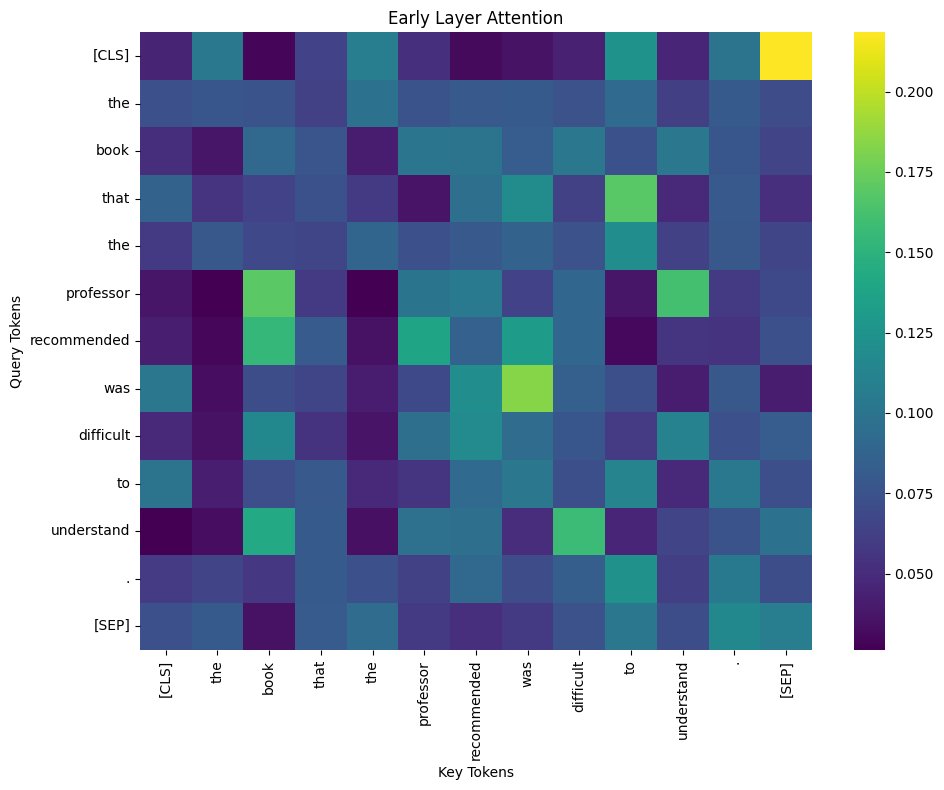

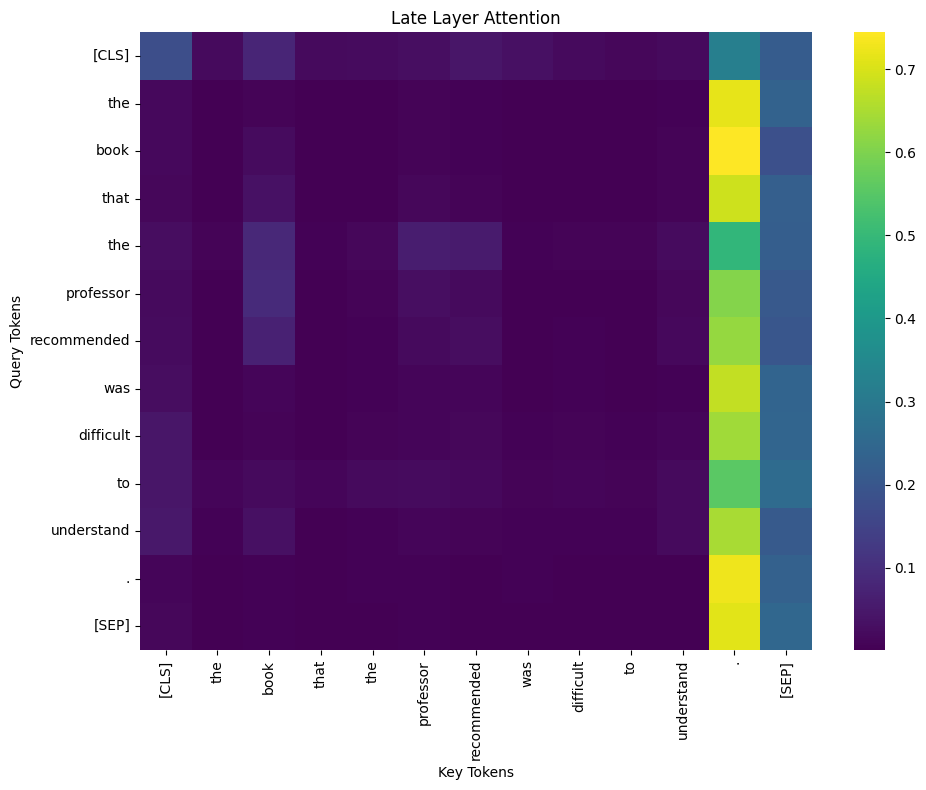

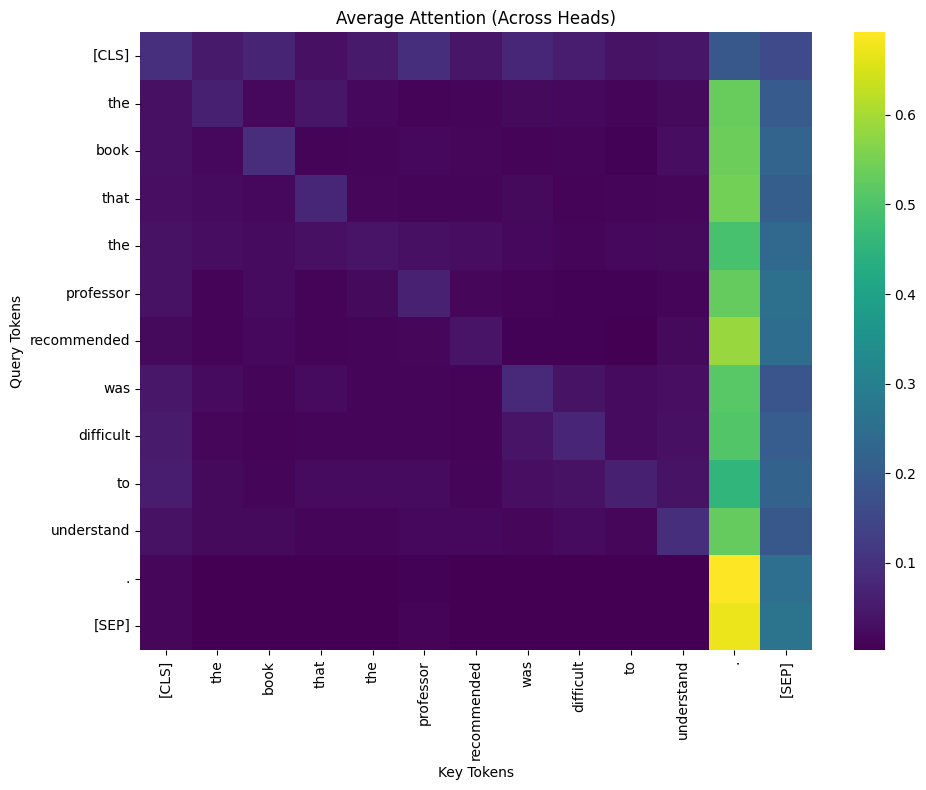

In [ ]:
# ------------------------------------------------------------
# Load Pretrained Model
# ------------------------------------------------------------

MODEL_NAME = "bert-base-uncased"

print("Loading model with attention outputs...")

# TODO: load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# TODO: load model with attention outputs enabled
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)

model.eval()
print("Model loaded successfully!\n")


# ------------------------------------------------------------
# Helper Function: Plot Attention Heatmap
# ------------------------------------------------------------

"""
TODO:

Implement a function that plots an attention heatmap.

Inputs:
- attention_matrix : (T, T) array
- tokens           : list of tokens
- title            : plot title

Use seaborn heatmap for visualization.
"""

def plot_attention(attention_matrix, tokens, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(title)
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Attention Analysis Loop
# ------------------------------------------------------------

for sentence_id, sentence in enumerate(ATTENTION_TEST_SENTENCES, 1):

    print("=" * 80)
    print(f"Sentence {sentence_id}:")
    print(sentence)
    print()

    # TODO: tokenize input sentence
    inputs = tokenizer(sentence, return_tensors="pt")

    # TODO: forward pass (no gradients required)
    with torch.no_grad():
        outputs = model(**inputs)

    # TODO: extract attention tensors
    attentions = outputs.attentions

    # TODO: convert token ids back to tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    print("Tokens:")
    print(tokens)
    print()

    ## DONOT MODIFY ANY OF THE FUNCTION CALLS BELOW

    # --------------------------------------------------------
    # TODO: Early layer attention
    # --------------------------------------------------------

    early_attention = attentions[0][0, 0].cpu().numpy()

    plot_attention(
        early_attention,
        tokens,
        title="Early Layer Attention"
    )

    # --------------------------------------------------------
    # TODO: Late layer attention
    # --------------------------------------------------------

    late_attention = attentions[-1][0, 0].cpu().numpy()

    plot_attention(
        late_attention,
        tokens,
        title="Late Layer Attention"
    )

    # --------------------------------------------------------
    # TODO: Average attention across heads
    # --------------------------------------------------------

    avg_attention = attentions[-1][0].mean(dim=0).cpu().numpy()

    plot_attention(
        avg_attention,
        tokens,
        title="Average Attention (Across Heads)"
    )

## Theoretical Questions: Attention Analysis (4 MARKS)

Answer the following questions based on the attention visualizations and observations from this task:

1. **Layer-wise Attention Behavior**  
   Compare the attention patterns from early layers and later layers. Do earlier layers focus more on nearby tokens while later layers capture longer-range relationships? Provide examples from the heatmaps to support your answer.

2. **Attention Head Specialization**  
   Do different attention heads appear to focus on different tokens or relationships within the same sentence? Describe any patterns you observe and explain why multiple attention heads might be useful.

3. **Interpretation of Attention**  
   Are tokens always attending most strongly to semantically related words? Identify at least one example where attention appears unintuitive or difficult to interpret. What does this suggest about using attention as an explanation for model behavior?

4. **Comparison with Your Transformer Implementation**  
   Based on your own Transformer implementation earlier in the assignment, explain how the attention mechanism used here is similar or different. Why might pretrained models exhibit clearer or more structured attention patterns?


Answers to the above mentioned questions:

1. Earlier layers consistently exhibit local attention, visible as bright diagonal line where tokens focus primarily on themselves and their immediate neighbours (in sentence 1 the WordPieces "ra" and "##dium" attend strongly to each other). As we move into the later layers, this diagonal fades into global patterns and "attention sinks". In late layer heatmaps, most tokens shift their focus toward tokens like [SEP]. This suggests that early layers handle low level tasks like reassembling words and basic grammar while later layers focus on high level sentence structure and global context.

2. Different attention heads within the same layer focus on distinct linguistic relationships. While single head we visualized often acts as a "sink" focusing on [SEP], the average attention plot shows a more distributed focus across the sentences, implying that other heads are tracking different features. Multiple heads are useful because language is multi-dimensional, one head tracks syntax like matching verbs to nouns, other handles coreference like matching "it" to "dog" another monitors punctuations.

3. Tokens do not always attend to semantically related words. They frequently focus on "no-op" tokens like [SEP] or "." that carry little narrative meaning. An unintuitive example in our heatmaps is the late layer behavior where almost every word in the sentence attends most strongly to the final [SEP] token rather than the subject of the sentence. This suggests that attention weights are not a perfect "explanation" of the models logic. Instead they are a mathematical mechanism for the model to "park" the unused weights, meaning we cannot always assume a high attention score equals a "human-like" understanding of a word's importance.

4. Mathematically the mechanism used here is similar to our MiniGPT implmentation relying on the scaled dot prodect formula;![image.png](attachment:image.png) However, our implementation used causal attention by masking the future, whereas BERT is Bidirectional, allowing tokens to "see" both left and right. Pretrained models exhibit a more structured patterns because they have been grounded by billons of coverage on stable linguistic rules, such as identifying that a pronoun like "who" should almost always attend a preceding noun like "scientist".


# Task 3: Applications of Pretrained Transformers
In the previous sections, you implemented and trained a Transformer model from scratch. While this helps understand how Transformers work internally, real-world NLP systems rarely train models from zero. Instead, practitioners rely on **pretrained Transformer models** that have already learned general language representations from massive datasets.

In this task, you will explore how pretrained Transformer models are used for **language understanding tasks**, rather than text generation.

Unlike your MiniGPT model (which is decoder-only and designed for generation), the models used here are **encoder-based Transformers**, optimized for understanding and analyzing text.

You will complete two industry-style tasks:

1. Zero-Shot Text Classification  
2. Part-of-Speech (POS) Tagging

## Part A — Zero-Shot Text Classification (7 MARKS)

### What is Zero-Shot Classification?

Zero-shot classification is a technique where a model assigns labels to text **without being explicitly trained on those specific labels beforehand**. Instead of learning a fixed set of categories during training, the model relies on its general language understanding to determine which label best matches the input.

For example:
Text: "The stock market crashed today."
Labels: ["finance", "sports", "politics"]
Output: finance


This ability comes from large-scale pretraining, where the model learns relationships between language concepts and can generalize to new tasks at inference time.

Zero-shot classification is widely used in industry for:

- automatic content tagging,
- moderation systems,
- routing user queries,
- organizing large document collections.

Unlike the Transformer you built earlier, which generates text autoregressively, zero-shot classification focuses on **understanding and categorizing text**.

---

### Your Task

In this section, you will use a pretrained Transformer model to classify sentences into categories without additional training.

You are required to:

1. Load a pretrained zero-shot classification model from HuggingFace.
2. Apply the model to all provided test sentences.
3. Predict the most suitable label from the candidate label set.
4. Report the predicted label along with the confidence score.

In [ ]:
# ------------------------------------------------------------
# Mandatory Test Sentences (Do Not Modify)
# ------------------------------------------------------------

ZERO_SHOT_SENTENCES = [
    "The government announced new economic reforms today.",
    "The team scored a last-minute goal to win the championship.",
    "Researchers developed a new AI model for medical diagnosis.",
    "The company reported record profits this quarter.",
    "A new smartphone was launched with improved battery life."
]
CANDIDATE_LABELS = ["politics", "sports", "technology", "business"]

In [ ]:
# ------------------------------------------------------------
# Load Pretrained Model
# ------------------------------------------------------------

"""
TODO:

Load a pretrained zero-shot classification model using
the HuggingFace pipeline API.

Suggested model:
- facebook/bart-large-mnli
"""
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")


# ------------------------------------------------------------
# Run Zero-Shot Classification
# ------------------------------------------------------------

print("=" * 80)

for idx, sentence in enumerate(ZERO_SHOT_SENTENCES, 1):

    print(f"\nSentence {idx}:")
    print(f'"{sentence}"\n')

    # TODO: run zero-shot classification
    result = classifier(sentence, CANDIDATE_LABELS)

    """
    TODO:

    Print:
    1. The predicted label
    2. The confidence score
    3. All candidate labels with their scores
    """
    print(f"Predicted label: {result['labels'][0]}")
    print(f"Confidence score: {result['scores'][0]:.4f}")
    print("\nAll candidate labels and scores:")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"{label}: {score:.4f}")

print("\n" + "=" * 80)
print("Zero-Shot Classification Complete!")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Sentence 1:
"The government announced new economic reforms today."

Predicted label: business
Confidence score: 0.5225

All candidate labels and scores:
business: 0.5225
politics: 0.3223
technology: 0.1015
sports: 0.0537

Sentence 2:
"The team scored a last-minute goal to win the championship."

Predicted label: sports
Confidence score: 0.9220

All candidate labels and scores:
sports: 0.9220
technology: 0.0436
business: 0.0256
politics: 0.0089

Sentence 3:
"Researchers developed a new AI model for medical diagnosis."

Predicted label: technology
Confidence score: 0.9880

All candidate labels and scores:
technology: 0.9880
business: 0.0062
sports: 0.0033
politics: 0.0024

Sentence 4:
"The company reported record profits this quarter."

Predicted label: business
Confidence score: 0.9721

All candidate labels and scores:
business: 0.9721
technology: 0.0193
sports: 0.0050
politics: 0.0035

Sentence 5:
"A new smartphone was launched with improved battery life."

Predicted label: technology

## Part B — Part-of-Speech (POS) Tagging (5 MARKS)

### What is Part-of-Speech Tagging?

Part-of-Speech (POS) tagging is the task of assigning a grammatical label to each word in a sentence based on its role in the sentence. Common POS categories include:

- **NOUN** — people, places, or things  
- **VERB** — actions or states  
- **ADJ** — descriptive words  
- **ADV** — modifiers of verbs or adjectives  
- **DET** — determiners (e.g., *the*, *a*)  
- **PRON** — pronouns  
- and other grammatical categories.

For example:
"The dog runs fast"
The (DET) dog (NOUN) runs (VERB) fast (ADV)

Unlike zero-shot classification, which assigns a single label to an entire sentence, POS tagging operates at the **token level**, predicting labels for individual words. This makes it a fundamental task for many language understanding systems.

POS tagging is commonly used in industry for:

- grammar and writing assistance tools,
- syntactic parsing,
- speech and language processing,
- information extraction pipelines.

---

### Your Task

In this section, you will use a pretrained Transformer model to assign part-of-speech tags to words in a sentence.

You are required to:

1. Load a pretrained POS tagging model from HuggingFace.
2. Apply the model to all provided test sentences.
3. Display each detected token along with its predicted POS tag.
4. Observe how the model handles punctuation, proper nouns, and ambiguous words.



In [ ]:
# ------------------------------------------------------------
# Mandatory Test Sentences (Do Not Modify)
# ------------------------------------------------------------
POS_TEST_SENTENCES = [
    "The quick brown fox jumps over the lazy dog.",
    "Marie Curie conducted pioneering research in radioactivity.",
    "Artificial intelligence is transforming modern industries.",
    "The students submitted their assignments before midnight.",
    "She carefully analyzed the experimental results."
]

In [ ]:
# ------------------------------------------------------------
# Load Pretrained POS Tagging Model
# ------------------------------------------------------------

"""
TODO:

Load a pretrained POS tagging model using the HuggingFace pipeline API.

Suggested model:
- vblagoje/bert-english-uncased-finetuned-pos

Use token-classification as the task.
"""

pos_tagger = pipeline("token-classification", model="vblagoje/bert-english-uncased-finetuned-pos")


# ------------------------------------------------------------
# Run POS Tagging
# ------------------------------------------------------------

print("=" * 80)

for idx, sentence in enumerate(POS_TEST_SENTENCES, 1):

    print(f"\nSentence {idx}:")
    print(f'"{sentence}"\n')

    # TODO: run POS tagging
    outputs = pos_tagger(sentence)

    """
    TODO:

    For each detected token:
    - extract the word
    - extract the predicted POS tag
    - extract the confidence score

    Print the results in a readable format.
    """
    for output in outputs:
        word = output["word"]
        pos_tag = output["entity"]
        score = output["score"]
        print(f"{word}: {pos_tag} (confidence: {score:.4f})")

print("\n" + "=" * 80)
print("POS Tagging Complete!")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: vblagoje/bert-english-uncased-finetuned-pos
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Sentence 1:
"The quick brown fox jumps over the lazy dog."

the: DET (confidence: 0.9994)
quick: ADJ (confidence: 0.9971)
brown: ADJ (confidence: 0.9423)
fox: NOUN (confidence: 0.9970)
jumps: VERB (confidence: 0.9994)
over: ADP (confidence: 0.9993)
the: DET (confidence: 0.9995)
lazy: ADJ (confidence: 0.9979)
dog: NOUN (confidence: 0.9989)
.: PUNCT (confidence: 0.9997)

Sentence 2:
"Marie Curie conducted pioneering research in radioactivity."

marie: PROPN (confidence: 0.9986)
cu: PROPN (confidence: 0.9975)
##rie: PROPN (confidence: 0.9980)
conducted: VERB (confidence: 0.9995)
pioneering: ADJ (confidence: 0.9237)
research: NOUN (confidence: 0.9988)
in: ADP (confidence: 0.9995)
radio: NOUN (confidence: 0.9962)
##act: NOUN (confidence: 0.9872)
##ivity: NOUN (confidence: 0.9989)
.: PUNCT (confidence: 0.9996)

Sentence 3:
"Artificial intelligence is transforming modern industries."

artificial: ADJ (confidence: 0.9926)
intelligence: NOUN (confidence: 0.9979)
is: AUX (confidence: 0.9980)
tr

Reference(s): https://machinelearningmastery.com/the-transformer-model/